# EVO-ECO Matrix: Cellular Plasticity as a Markov Decision Process
## Q-Learning Simulation — Cancer Cell Survival Strategy

**Core question:** At what metabolic cost does phenotypic plasticity become worse than proliferating and waiting for a random mutation?

## Biology Rules (from biology team specification)

These rules implement the **Cancer Cell Decision and Evolution Model** as defined by the biology team. The cell-agent operates in a 32-state MDP (Phenotype × Genotype × Therapy × Resources × Hazards) with 3 actions (Proliferate, Quiesce, Switch). The engine below reads from `BioConfig` and does NOT need to change.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BIOLOGY RULES — from biology team specification
# ============================================================

class BioConfig:
    """
    All biology-defined parameters live here.
    State = (Phenotype, Genotype, Therapy, Resources, Hazards)
    Each dimension is binary → 2^5 = 32 states.
    """

    # --- STATE ENCODING ---
    # State index = phenotype*16 + genotype*8 + therapy*4 + resources*2 + hazards
    # Phenotype: 0=Differentiated (D), 1=Stem-like (S)
    # Genotype:  0=Sensitive, 1=Resistant
    # Therapy:   0=OFF, 1=ON
    # Resources: 0=Low, 1=High
    # Hazards:   0=Low, 1=High
    NUM_STATES = 32

    # Hady: States dimensions => what do I have from those at this current point in time
    STATE_DIMS = ["Phenotype", "Genotype", "Therapy", "Resources", "Hazards"]

    # Hady: Only the first two is modeled while the rest are left as it is since it does not show straight up binary
    PHENOTYPE_NAMES = {0: "D", 1: "S"}
    GENOTYPE_NAMES = {0: "Sensitive", 1: "Resistant"}

    # Hady: Convenience utility method to mark an entry in the Q-Table(encode method)
    @staticmethod
    def encode_state(phenotype, genotype, therapy, resources, hazards):
        return phenotype * 16 + genotype * 8 + therapy * 4 + resources * 2 + hazards

    # Hady: Convenience utility method to mark an entry in the Q-Table(decode method)
    @staticmethod
    def decode_state(state_index):
        hazards   = state_index % 2
        resources = (state_index // 2) % 2
        therapy   = (state_index // 4) % 2
        genotype  = (state_index // 8) % 2
        phenotype = (state_index // 16) % 2
        return phenotype, genotype, therapy, resources, hazards

    # Hady: Prints in a readable way
    @staticmethod
    def state_label(state_index):
        p, g, t, r, h = BioConfig.decode_state(state_index)
        return (f"{'S' if p else 'D'}|"
                f"G{g}|"
                f"T{'on' if t else 'off'}|"
                f"R{'H' if r else 'L'}|"
                f"H{'H' if h else 'L'}")

    # Build STATES dict for compatibility with engine/viewer
    # Hady: it aggregates the generation of all the states
    STATES = {i: None for i in range(32)}
    for _i in range(32):
        STATES[_i] = (
            f"{'S' if (_i//16)%2 else 'D'}|"
            f"G{(_i//8)%2}|"
            f"T{'on' if (_i//4)%2 else 'off'}|"
            f"R{'H' if (_i//2)%2 else 'L'}|"
            f"H{'H' if _i%2 else 'L'}"
        )

    # Hady: The actions possible to be taken
    # --- ACTIONS ---
    ACTIONS = {
        0: "Proliferate",   # divide — gain fitness but face hazards
        1: "Quiesce",       # go dormant — lower hazard exposure
        2: "Switch",        # flip phenotype D↔S (plasticity)
    }
    NUM_ACTIONS = len(ACTIONS)

    # --- DEATH PROBABILITY TABLE ---
    # Key: (therapy, hazards, resources, phenotype) → base death probability
    # From biology team specification table
    DEATH_PROB = {
        # Therapy ON + Hazards High + Resources Low  → harshest
        (1, 1, 0, 0): 0.60,   # D cell
        (1, 1, 0, 1): 0.15,   # S cell
        # Therapy ON + Hazards High + Resources High
        (1, 1, 1, 0): 0.35,   # D cell
        (1, 1, 1, 1): 0.15,   # S cell (low-moderate)
        # Therapy OFF + Hazards Low + Resources High  → safest
        (0, 0, 1, 0): 0.05,   # D cell
        (0, 0, 1, 1): 0.05,   # S cell
        # Therapy OFF + Resources Low (hypoxia)
        (0, 0, 0, 0): 0.15,   # D cell
        (0, 0, 0, 1): 0.15,   # S cell (low-moderate)
        # Fill in remaining combos with reasonable interpolations:
        # Therapy ON + Hazards Low (therapy present but low external threat)
        (1, 0, 0, 0): 0.35,   # D cell — therapy still kills
        (1, 0, 0, 1): 0.10,   # S cell — stress tolerant
        (1, 0, 1, 0): 0.25,   # D cell — therapy + good resources
        (1, 0, 1, 1): 0.08,   # S cell
        # Therapy OFF + Hazards High (immune predation, no drug)
        (0, 1, 0, 0): 0.25,   # D cell
        (0, 1, 0, 1): 0.10,   # S cell
        (0, 1, 1, 0): 0.15,   # D cell
        (0, 1, 1, 1): 0.08,   # S cell
    }

    # Hady: Simply return the death probability
    @staticmethod
    def get_death_prob(therapy, hazards, resources, phenotype):
        return BioConfig.DEATH_PROB[(therapy, hazards, resources, phenotype)]

    # --- MUTATION ---
    MUTATION_PROB_BASE = 0.002      # mu0: base mutation rate per proliferation
    EVO_MULTIPLIER = 1.0            # f(Evo): scale factor (1 for low Evo, up to 10 for high)

    # --- ENVIRONMENT DYNAMICS ---
    # Each step, therapy/resources/hazards stochastically toggle
    # This flips the environment with 10% for each step,
    # Assumption that I made because there is no way to change the environment,
    # So I added the probability 
    ENV_TOGGLE_PROB = 0.10          # 10% chance each flips per step

    # --- REWARD FUNCTION ---
    SURVIVAL_REWARD = 1.0           # +1 for surviving a step (Biology team)
    PROLIFERATION_BONUS = 2.0       # +2 if proliferate and survive (Biology team)
    DEATH_PENALTY = -10.0           # -10 if cell dies (Biology team)
    QUIESCENCE_COST = 0.1           # -0.1 for quiescing (opportunity cost) (Biology team)

    # Plasticity cost — THIS IS THE PARAMETER WE SWEEP
    # Hady: Not mentioned in the rules, I made the assumption
    PLASTICITY_COST = 0.3           # default; sweep loop overrides (Biology team)

    # --- QUIESCENCE HAZARD REDUCTION ---
    QUIESCE_DEATH_MULTIPLIER = 0.5  # quiescing halves death probability

    # --- GENETIC RESISTANCE ---
    RESISTANCE_DEATH_MULTIPLIER = 0.5  # resistant cells have halved death prob

    # --- TRANSITION LOGIC ---
    @staticmethod
    def transition(state, action, plasticity_cost_override=None):
        """
        Given current state index and action, return (next_state, reward, done).
        Implements the biology team's Cancer Cell Decision and Evolution Model.
        """
        phenotype, genotype, therapy, resources, hazards = BioConfig.decode_state(state)
        plast_cost = (plasticity_cost_override
                      if plasticity_cost_override is not None
                      else BioConfig.PLASTICITY_COST)

        reward = 0.0

        # --- 1. Apply action ---
        if action == 0:  # Proliferate
            # Mutation check: only when proliferating and genotype=0
            if genotype == 0:
                mu_eff = BioConfig.MUTATION_PROB_BASE * BioConfig.EVO_MULTIPLIER
                if np.random.rand() < mu_eff:
                    genotype = 1  # acquired genetic resistance

        elif action == 1:  # Quiesce
            pass  # no state change; death prob reduced below

        elif action == 2:  # Switch phenotype (plasticity)
            phenotype = 1 - phenotype  # flip D↔S
            reward -= plast_cost

        # --- 2. Stochastically toggle environment ---
        if np.random.rand() < BioConfig.ENV_TOGGLE_PROB:
            therapy = 1 - therapy
        if np.random.rand() < BioConfig.ENV_TOGGLE_PROB:
            resources = 1 - resources
        if np.random.rand() < BioConfig.ENV_TOGGLE_PROB:
            hazards = 1 - hazards

        # --- 3. Compute death probability ---
        death_prob = BioConfig.get_death_prob(therapy, hazards, resources, phenotype)

        # Genetic resistance halves death probability
        if genotype == 1:
            death_prob *= BioConfig.RESISTANCE_DEATH_MULTIPLIER

        # Quiescence reduces hazard exposure
        if action == 1:
            death_prob *= BioConfig.QUIESCE_DEATH_MULTIPLIER

        # --- 4. Survival check ---
        if np.random.rand() < death_prob:
            next_state = BioConfig.encode_state(phenotype, genotype, therapy, resources, hazards)
            return next_state, BioConfig.DEATH_PENALTY, True  # cell dies

        # --- 5. Compute reward ---
        reward += BioConfig.SURVIVAL_REWARD  # +1 for surviving

        if action == 0:  # Proliferate bonus
            reward += BioConfig.PROLIFERATION_BONUS

        if action == 1:  # Quiescence opportunity cost
            reward -= BioConfig.QUIESCENCE_COST

        next_state = BioConfig.encode_state(phenotype, genotype, therapy, resources, hazards)
        return next_state, reward, False


print("Biology rules loaded (real rules from biology team).")
print(f"  States:  {BioConfig.NUM_STATES} (5 binary dimensions)")
print(f"  Actions: {list(BioConfig.ACTIONS.values())}")
print(f"  Default plasticity cost: {BioConfig.PLASTICITY_COST}")
print(f"  Death penalty: {BioConfig.DEATH_PENALTY}")
print(f"  Proliferation bonus: +{BioConfig.PROLIFERATION_BONUS}")
print(f"  Example state 0: {BioConfig.state_label(0)}")
print(f"  Example state 31: {BioConfig.state_label(31)}")

Biology rules loaded (real rules from biology team).
  States:  32 (5 binary dimensions)
  Actions: ['Proliferate', 'Quiesce', 'Switch']
  Default plasticity cost: 0.3
  Death penalty: -10.0
  Proliferation bonus: +2.0
  Example state 0: D|G0|Toff|RL|HL
  Example state 31: S|G1|Ton|RH|HH


## BioConfig Flowchart — Cancer Cell Decision and Evolution Model

Visual map of the cancer cell's decision process, showing the 5-dimensional state space, 3 actions, and transition logic from the biology team specification.

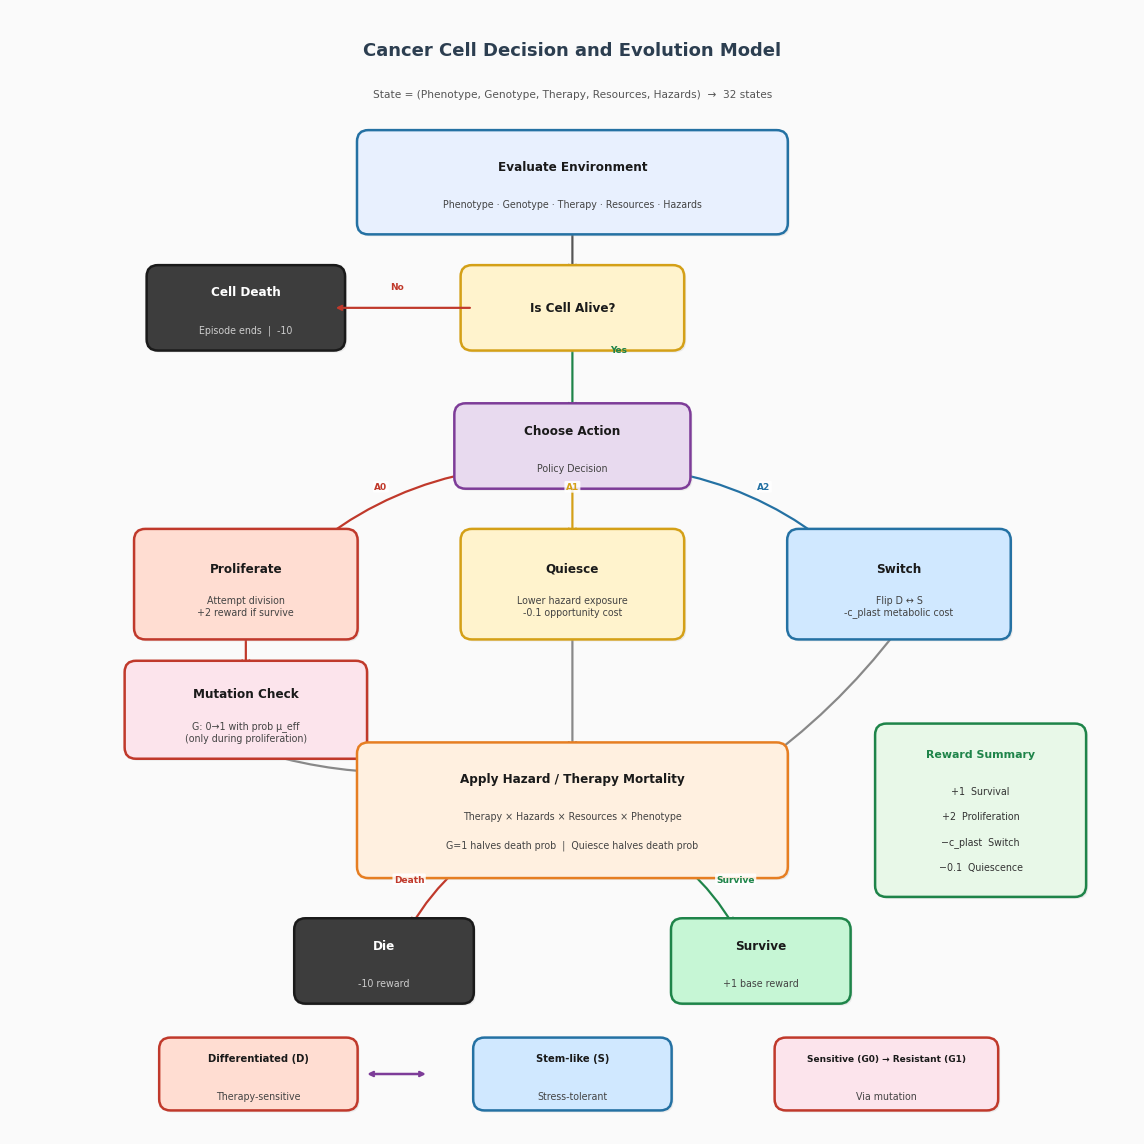

Flowchart saved to bioconfig_flowchart.png


In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(18, 16))
ax.set_xlim(-1, 17)
ax.set_ylim(-2, 16)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

TITLE_FS = 16
BOX_FS = 12
SUB_FS = 9.5
ARROW_FS = 9

# ── Helper: draw a rounded box ──
def draw_box(ax, cx, cy, w, h, text, subtitle, facecolor, edgecolor,
             fs=BOX_FS, text_color='#1A1A1A', sub_color='#444444'):
    box = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                         boxstyle="round,pad=0.18", facecolor=facecolor,
                         edgecolor=edgecolor, linewidth=2.5, zorder=3)
    box.set_path_effects([pe.withSimplePatchShadow(offset=(2, -2),
                         shadow_rgbFace='#BBBBBB', alpha=0.25)])
    ax.add_patch(box)
    if text:
        y_text = cy + (0.25 if subtitle else 0)
        ax.text(cx, y_text, text, ha='center', va='center', fontsize=fs,
                fontweight='bold', color=text_color, zorder=4)
    if subtitle:
        ax.text(cx, cy - 0.35, subtitle, ha='center', va='center', fontsize=SUB_FS,
                color=sub_color, zorder=4)

def arrow(ax, start, end, label, color, rad=0.0, label_offset=(0, 0.35)):
    arr = FancyArrowPatch(start, end,
              arrowstyle='->', mutation_scale=18,
              connectionstyle=f"arc3,rad={rad}",
              color=color, linewidth=2.2, zorder=2)
    ax.add_patch(arr)
    if label:
        mx = (start[0] + end[0]) / 2 + label_offset[0]
        my = (start[1] + end[1]) / 2 + label_offset[1]
        ax.text(mx, my, label, ha='center', va='center',
                fontsize=ARROW_FS, color=color, fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='none', alpha=0.85))

# ── Title ──
ax.text(8, 15.3, "Cancer Cell Decision and Evolution Model",
        ha='center', va='center', fontsize=TITLE_FS + 2, fontweight='bold', color='#2C3E50')
ax.text(8, 14.6, "State = (Phenotype, Genotype, Therapy, Resources, Hazards)  →  32 states",
        ha='center', va='center', fontsize=SUB_FS + 1, color='#555555')

# ── 1. Evaluate Environment (top center) ──
draw_box(ax, 8, 13.2, 6.5, 1.3,
         "Evaluate Environment",
         "Phenotype · Genotype · Therapy · Resources · Hazards",
         '#E8F0FE', '#2471A3')

# ── 2. Is Cell Alive? ──
draw_box(ax, 8, 11.2, 3.2, 1.0, "Is Cell Alive?", "", '#FFF3CD', '#D4A017')
arrow(ax, (8, 12.55), (8, 11.7), "", '#555555')

# ── 3. Cell Death (left of alive check) ──
draw_box(ax, 2.8, 11.2, 2.8, 1.0, "Cell Death", "Episode ends  |  -10",
         '#3D3D3D', '#1A1A1A', text_color='white', sub_color='#CCCCCC')
ax.text(5.1, 11.5, "No", fontsize=ARROW_FS, fontweight='bold', color='#C0392B', zorder=5)
ax.annotate("", xy=(4.2, 11.2), xytext=(6.4, 11.2),
            arrowprops=dict(arrowstyle="->", color='#C0392B', lw=2.2))

# ── 4. Choose Action ──
draw_box(ax, 8, 9.0, 3.4, 1.0, "Choose Action", "Policy Decision", '#E8DAEF', '#7D3C98')
ax.text(8.6, 10.5, "Yes", fontsize=ARROW_FS, fontweight='bold', color='#1E8449', zorder=5)
arrow(ax, (8, 10.7), (8, 9.5), "", '#1E8449')

# ── 5. Three actions ──
action_y = 6.8

# Proliferate (left)
draw_box(ax, 2.8, action_y, 3.2, 1.4, "Proliferate",
         "Attempt division\n+2 reward if survive",
         '#FFDDD2', '#C0392B')
# Quiesce (center)
draw_box(ax, 8, action_y, 3.2, 1.4, "Quiesce",
         "Lower hazard exposure\n-0.1 opportunity cost",
         '#FFF3CD', '#D4A017')
# Switch (right)
draw_box(ax, 13.2, action_y, 3.2, 1.4, "Switch",
         "Flip D ↔ S\n-c_plast metabolic cost",
         '#D0E8FF', '#2471A3')

# Action arrows from Choose Action
arrow(ax, (6.5, 8.6), (4.0, 7.5), "A0", '#C0392B', rad=0.12, label_offset=(-0.3, 0.3))
arrow(ax, (8, 8.5), (8, 7.5), "A1", '#D4A017')
arrow(ax, (9.5, 8.6), (12.0, 7.5), "A2", '#2471A3', rad=-0.12, label_offset=(0.3, 0.3))

# ── 6. Mutation Check (below Proliferate) ──
draw_box(ax, 2.8, 4.8, 3.5, 1.2, "Mutation Check",
         "G: 0→1 with prob μ_eff\n(only during proliferation)",
         '#FCE4EC', '#C0392B')
arrow(ax, (2.8, 6.1), (2.8, 5.4), "", '#C0392B')

# ── 7. Apply Hazard / Therapy Mortality (center) ──
draw_box(ax, 8, 3.2, 6.5, 1.8, "", "", '#FFF0E0', '#E67E22')
ax.text(8, 3.7, "Apply Hazard / Therapy Mortality", ha='center', va='center',
        fontsize=BOX_FS, fontweight='bold', color='#1A1A1A', zorder=5)
ax.text(8, 3.1, "Therapy × Hazards × Resources × Phenotype",
        ha='center', va='center', fontsize=SUB_FS, color='#444444', zorder=5)
ax.text(8, 2.65, "G=1 halves death prob  |  Quiesce halves death prob",
        ha='center', va='center', fontsize=SUB_FS, color='#444444', zorder=5)

# Arrows into hazard box
arrow(ax, (2.8, 4.2), (5.2, 3.8), "", '#888888', rad=0.08)
arrow(ax, (8, 6.1), (8, 4.1), "", '#888888')
arrow(ax, (13.2, 6.1), (10.8, 3.8), "", '#888888', rad=-0.08)

# ── 8. Die / Survive outcomes ──
draw_box(ax, 5.0, 0.8, 2.5, 1.0, "Die", "-10 reward",
         '#3D3D3D', '#1A1A1A', text_color='white', sub_color='#CCCCCC')
draw_box(ax, 11.0, 0.8, 2.5, 1.0, "Survive", "+1 base reward", '#C6F6D5', '#1E8449')

arrow(ax, (6.2, 2.3), (5.4, 1.3), "Death", '#C0392B', rad=0.08, label_offset=(-0.4, 0.3))
arrow(ax, (9.8, 2.3), (10.6, 1.3), "Survive", '#1E8449', rad=-0.08, label_offset=(0.4, 0.3))

# ── Reward Summary box (right side) ──
draw_box(ax, 14.5, 3.2, 3.0, 2.4, "", "", '#E8F8E8', '#1E8449')
ax.text(14.5, 4.1, "Reward Summary", ha='center', va='center', fontsize=BOX_FS - 1,
        fontweight='bold', color='#1E8449', zorder=5)
reward_lines = ["+1  Survival", "+2  Proliferation", "−c_plast  Switch", "−0.1  Quiescence"]
for i, line in enumerate(reward_lines):
    ax.text(14.5, 3.5 - i * 0.4, line, ha='center', va='center',
            fontsize=SUB_FS, color='#333', zorder=5)

# ── Phenotype legend at bottom ──
legend_y = -1.0
draw_box(ax, 3, legend_y, 2.8, 0.8, "Differentiated (D)", "Therapy-sensitive",
         '#FFDDD2', '#C0392B', fs=10)
draw_box(ax, 8, legend_y, 2.8, 0.8, "Stem-like (S)", "Stress-tolerant",
         '#D0E8FF', '#2471A3', fs=10)
draw_box(ax, 13, legend_y, 3.2, 0.8, "Sensitive (G0) → Resistant (G1)", "Via mutation",
         '#FCE4EC', '#C0392B', fs=9)

# D ↔ S arrow
ax.annotate("", xy=(5.7, legend_y), xytext=(4.7, legend_y),
            arrowprops=dict(arrowstyle="<->", color='#7D3C98', lw=2.5))

plt.tight_layout()
plt.savefig("bioconfig_flowchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Flowchart saved to bioconfig_flowchart.png")

## Q-Learning Engine

This cell is **generic**. It reads states/actions/transitions from `BioConfig` and does not need to change when biology rules are updated.

In [5]:
class QLearningEngine:
    """
    Tabular Q-learning agent.
    Reads state/action dimensions from BioConfig.
    Now handles 32 states × 3 actions.
    """

    def __init__(self, lr=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.lr = lr                # learning rate
        self.gamma = gamma          # discount factor
        self.epsilon = epsilon      # exploration rate
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table: rows = states (32), cols = actions (3)
        # Hady: we are mapping to q-table of 32 states and 3 actions
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))

    # Epsilon greedy so this parameter, I am randomly exploring at first
    # and down the line I become more greedy I pick the options that benefit me the most
    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(BioConfig.NUM_ACTIONS)
        return int(np.argmax(self.q_table[state]))

    # Update the Q-Table, learning rate represents how much to react to new experiences
    def update(self, state, action, reward, next_state, done):
        """Standard Q-learning update rule."""
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state, action] += self.lr * (target - self.q_table[state, action])

    # This method decays the epsilon to facilitate the behaviour of being random at first then more greedy
    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    # This is a utility method used for reset
    def reset(self):
        """Reset Q-table and epsilon for a fresh training run."""
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))
        self.epsilon = 1.0


def print_qtable(agent: QLearningEngine):
    """Pretty-print the agent's Q-table with state/action names and best action markers."""
    col_width = 14
    header = f"{'State':<24} |"
    for a in range(BioConfig.NUM_ACTIONS):
        header += f" A{a}: {BioConfig.ACTIONS[a]:<{col_width - 4}} |"
    header += " Best Action"
    print("=" * len(header))
    print("  Q-Table (32 states × 3 actions)")
    print("=" * len(header))
    print(header)
    print("-" * len(header))
    for s in range(BioConfig.NUM_STATES):
        best_a = int(np.argmax(agent.q_table[s]))
        # Only print states that have been visited (non-zero Q-values)
        if np.any(agent.q_table[s] != 0):
            row = f"{BioConfig.state_label(s):<24} |"
            for a in range(BioConfig.NUM_ACTIONS):
                val = agent.q_table[s, a]
                marker = " *" if a == best_a else "  "
                row += f" {val:>+{col_width - 3}.2f}{marker} |"
            row += f" {BioConfig.ACTIONS[best_a]}"
            print(row)
    print("=" * len(header))
    print("  * = greedy-best action for that state (only visited states shown)")


# Starting state: Differentiated, Sensitive, Therapy ON, Resources High, Hazards High
# (a stressed cell under therapy — the most interesting starting condition)
DEFAULT_START_STATE = BioConfig.encode_state(
    phenotype=0, genotype=0, therapy=1, resources=1, hazards=1
)


def run_episode(agent: QLearningEngine, max_steps=1000, plasticity_cost=None):
    """Run one episode, updating the agent's Q-table at each step."""
    state = DEFAULT_START_STATE
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = BioConfig.transition(state, action,
                                                         plasticity_cost_override=plasticity_cost)
        agent.update(state, action, reward, next_state, done)
        total_reward += reward
        state = next_state
        if done:
            break

    return total_reward


def train_agent(plasticity_cost=None, num_episodes=1000, max_steps=1000):
    """Train a Q-learning agent and return (agent, episode_rewards)."""
    agent = QLearningEngine()
    rewards = []
    for ep in range(num_episodes):
        ep_reward = run_episode(agent, max_steps, plasticity_cost)
        rewards.append(ep_reward)
        agent.decay_epsilon()
    return agent, rewards


print(f"Q-Learning engine ready.")
print(f"  Q-table shape: ({BioConfig.NUM_STATES}, {BioConfig.NUM_ACTIONS})")
print(f"  Start state: {BioConfig.state_label(DEFAULT_START_STATE)}")
print(f"  Training episodes: 1000 (default)")

# Quick sanity check: train and show Q-table
agent, _ = train_agent(num_episodes=1000, max_steps=1000)
print(f"\nAfter 1000 episodes of training:")
print_qtable(agent)

Q-Learning engine ready.
  Q-table shape: (32, 3)
  Start state: D|G0|Ton|RH|HH
  Training episodes: 1000 (default)

After 1000 episodes of training:
  Q-Table (32 states × 3 actions)
State                    | A0: Proliferate | A1: Quiesce    | A2: Switch     | Best Action
------------------------------------------------------------------------------------------
D|G0|Toff|RL|HL          |       -0.34   |       -0.23   |       +4.23 * | Switch
D|G0|Toff|RL|HH          |       -0.36   |       -1.11   |       +3.01 * | Switch
D|G0|Toff|RH|HL          |       +6.74 * |       +1.94   |       +2.15   | Proliferate
D|G0|Toff|RH|HH          |       +1.45   |       -0.56   |       +4.08 * | Switch
D|G0|Ton|RL|HL           |       -2.42   |       -0.52   |       +4.16 * | Switch
D|G0|Ton|RL|HH           |       -0.72   |       -0.78   |       +3.27 * | Switch
D|G0|Ton|RH|HL           |       +1.75   |       -2.21   |       +4.56 * | Switch
D|G0|Ton|RH|HH           |       -0.88   |       -0.56 

## Interactive Step-Through Viewer

Walk through the Q-learning process one step at a time. This launches a **Tkinter window** with Prev/Next buttons that let you inspect each state transition, action chosen, reward received, and the evolving Q-table across multiple episodes.

- **State indicators** use the same color scheme as the flowchart above
- **Q-table** highlights the action chosen (yellow) and the greedy-best action (bold)
- **Episode summaries** appear between episodes showing outcome (died / survived / mutant)
- Use **Left/Right arrow keys** or the buttons to navigate
- Close the window to continue to the sweep section below

In [7]:
import tkinter as tk

# === CONFIGURATION ===
VIEWER_NUM_EPISODES = 500    # number of episodes to record
VIEWER_MAX_STEPS = 1000      # max steps per episode
VIEWER_PLASTICITY_COST = None  # None = use BioConfig default

# === COLORS based on phenotype ===
def get_state_colors(state_idx):
    p, g, t, r, h = BioConfig.decode_state(state_idx)
    if p == 0:  # Differentiated
        return {"bg": "#FFDDD2", "border": "#C0392B"}
    else:       # Stem-like
        return {"bg": "#D0E8FF", "border": "#2471A3"}

# === RECORD EPISODES (with calculation intermediates) ===
def record_episodes(num_episodes, max_steps, plasticity_cost):
    agent = QLearningEngine()
    timeline = []

    for ep in range(num_episodes):
        state = DEFAULT_START_STATE
        cumulative_reward = 0.0
        ep_steps = 0
        died = False

        for step in range(max_steps):
            # --- Action selection (inlined to capture metadata) ---
            greedy_action = int(np.argmax(agent.q_table[state]))
            greedy_q_value = float(agent.q_table[state, greedy_action])
            if np.random.rand() < agent.epsilon:
                action = np.random.randint(BioConfig.NUM_ACTIONS)
                was_random = True
            else:
                action = greedy_action
                was_random = False

            # --- Environment step ---
            next_state, reward, done = BioConfig.transition(
                state, action, plasticity_cost_override=plasticity_cost
            )

            # --- Q-value update (inlined to capture intermediates) ---
            old_q_value = float(agent.q_table[state, action])
            max_next_q = float(np.max(agent.q_table[next_state]))
            if done:
                target = reward
            else:
                target = reward + agent.gamma * max_next_q
            td_error = target - old_q_value
            agent.q_table[state, action] += agent.lr * td_error
            new_q_value = float(agent.q_table[state, action])

            cumulative_reward += reward
            ep_steps += 1

            timeline.append({
                "type": "step",
                "episode": ep,
                "step": step,
                "state": state,
                "state_name": BioConfig.state_label(state),
                "action": action,
                "action_name": BioConfig.ACTIONS[action],
                "reward": reward,
                "next_state": next_state,
                "next_state_name": BioConfig.state_label(next_state),
                "done": done,
                "cumulative_reward": cumulative_reward,
                "q_table_snapshot": agent.q_table.copy(),
                "epsilon": agent.epsilon,
                "was_random": was_random,
                "greedy_action": greedy_action,
                "greedy_action_name": BioConfig.ACTIONS[greedy_action],
                "greedy_q_value": greedy_q_value,
                "old_q_value": old_q_value,
                "max_next_q": max_next_q,
                "target": target,
                "td_error": td_error,
                "new_q_value": new_q_value,
            })

            state = next_state
            if done:
                died = True
                break

        # Decode final state for summary
        p, g, t, r, h = BioConfig.decode_state(state)
        timeline.append({
            "type": "summary",
            "episode": ep,
            "total_steps": ep_steps,
            "total_reward": cumulative_reward,
            "final_state": state,
            "final_state_name": BioConfig.state_label(state),
            "died": died,
            "genotype": g,
        })

        agent.decay_epsilon()

    return timeline, agent

# Record the episodes
timeline, _ = record_episodes(VIEWER_NUM_EPISODES, VIEWER_MAX_STEPS, VIEWER_PLASTICITY_COST)

# Count steps per episode for header display
ep_step_counts = {}
for entry in timeline:
    if entry["type"] == "summary":
        ep_step_counts[entry["episode"]] = entry["total_steps"]

print(f"Recorded {len(timeline)} timeline entries across {VIEWER_NUM_EPISODES} episodes.")
print("Launching viewer...")

# === TKINTER GUI ===
current_index = 0

root = tk.Tk()
root.title("Cancer Cell MDP — Episode Step-Through Viewer (32-State Model)")
root.configure(bg="#FAFAFA")
root.geometry("800x1050")
root.resizable(True, True)
root.minsize(600, 400)

FONT_HEADER = ("Segoe UI", 14, "bold")
FONT_LABEL = ("Segoe UI", 10, "bold")
FONT_VALUE = ("Consolas", 10)
FONT_STATE = ("Segoe UI", 10)
FONT_QTABLE = ("Consolas", 9)
FONT_SUMMARY_TITLE = ("Segoe UI", 16, "bold")
FONT_SUMMARY = ("Consolas", 11)
FONT_HINT = ("Segoe UI", 9, "italic")
FONT_CALC = ("Consolas", 10)
FONT_CALC_BOLD = ("Consolas", 10, "bold")
BG = "#FAFAFA"

# --- Scrollable container ---
outer_frame = tk.Frame(root, bg=BG)
outer_frame.pack(fill=tk.BOTH, expand=True)

canvas = tk.Canvas(outer_frame, bg=BG, highlightthickness=0)
v_scrollbar = tk.Scrollbar(outer_frame, orient=tk.VERTICAL, command=canvas.yview)
canvas.configure(yscrollcommand=v_scrollbar.set)

v_scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)

scroll_frame = tk.Frame(canvas, bg=BG)
canvas_window = canvas.create_window((0, 0), window=scroll_frame, anchor="nw")

def _on_frame_configure(event):
    canvas.configure(scrollregion=canvas.bbox("all"))

def _on_canvas_configure(event):
    canvas.itemconfig(canvas_window, width=event.width)

scroll_frame.bind("<Configure>", _on_frame_configure)
canvas.bind("<Configure>", _on_canvas_configure)

def _on_mousewheel(event):
    canvas.yview_scroll(int(-1 * (event.delta / 120)), "units")

canvas.bind_all("<MouseWheel>", _on_mousewheel)

# --- Header frame ---
header_frame = tk.Frame(scroll_frame, bg=BG, pady=10)
header_frame.pack(fill=tk.X, padx=15)

lbl_episode = tk.Label(header_frame, text="", font=FONT_HEADER, bg=BG)
lbl_episode.pack(side=tk.LEFT, padx=(0, 30))

lbl_step = tk.Label(header_frame, text="", font=FONT_HEADER, bg=BG)
lbl_step.pack(side=tk.LEFT, padx=(0, 30))

lbl_epsilon = tk.Label(header_frame, text="", font=("Segoe UI", 10), bg=BG, fg="#718096")
lbl_epsilon.pack(side=tk.RIGHT)

# --- Separator ---
tk.Frame(scroll_frame, height=2, bg="#E2E8F0").pack(fill=tk.X, padx=15, pady=5)

# --- State decomposition display ---
state_decomp_frame = tk.LabelFrame(scroll_frame, text="Current State Decomposition",
                                    font=FONT_LABEL, bg=BG, padx=12, pady=8)
state_decomp_frame.pack(fill=tk.X, padx=15, pady=5)

state_dim_labels = {}
dim_names = ["Phenotype", "Genotype", "Therapy", "Resources", "Hazards"]
dim_colors = {
    "Phenotype": {"D": ("#FFDDD2", "#C0392B"), "S": ("#D0E8FF", "#2471A3")},
    "Genotype": {"Sensitive": ("#E8F8E8", "#1E8449"), "Resistant": ("#FCE4EC", "#C0392B")},
    "Therapy": {"OFF": ("#E8F8E8", "#1E8449"), "ON": ("#FCE4EC", "#C0392B")},
    "Resources": {"Low": ("#FFF3CD", "#D4A017"), "High": ("#E8F8E8", "#1E8449")},
    "Hazards": {"Low": ("#E8F8E8", "#1E8449"), "High": ("#FCE4EC", "#C0392B")},
}
for i, dim in enumerate(dim_names):
    tk.Label(state_decomp_frame, text=f"{dim}:", font=FONT_LABEL, bg=BG,
             anchor=tk.W).grid(row=0, column=i*2, padx=(8, 2))
    val_lbl = tk.Label(state_decomp_frame, text="—", font=("Segoe UI", 10, "bold"),
                       bg="#E8E8E8", padx=8, pady=3, relief=tk.RIDGE)
    val_lbl.grid(row=0, column=i*2+1, padx=(0, 8))
    state_dim_labels[dim] = val_lbl

def update_state_decomp(state_idx):
    p, g, t, r, h = BioConfig.decode_state(state_idx)
    vals = {
        "Phenotype": "D" if p == 0 else "S",
        "Genotype": "Sensitive" if g == 0 else "Resistant",
        "Therapy": "OFF" if t == 0 else "ON",
        "Resources": "Low" if r == 0 else "High",
        "Hazards": "Low" if h == 0 else "High",
    }
    for dim, val in vals.items():
        lbl = state_dim_labels[dim]
        bg, fg = dim_colors[dim][val]
        lbl.config(text=val, bg=bg, fg=fg)

# --- Info frame (step details) ---
info_frame = tk.LabelFrame(scroll_frame, text="Step Details", font=FONT_LABEL,
                           bg=BG, padx=12, pady=10)

info_fields = {}
field_defs = [
    ("State", "state_display"),
    ("Action", "action_display"),
    ("Reward", "reward_display"),
    ("Next State", "next_state_display"),
    ("Done", "done_display"),
    ("Cumul. Reward", "cumul_display"),
]
for row, (label_text, key) in enumerate(field_defs):
    tk.Label(info_frame, text=f"{label_text}:", font=FONT_LABEL,
             bg=BG, anchor=tk.W).grid(row=row, column=0, sticky=tk.W, padx=(0, 20), pady=3)
    val_lbl = tk.Label(info_frame, text="", font=FONT_VALUE, bg=BG, anchor=tk.W)
    val_lbl.grid(row=row, column=1, sticky=tk.W, pady=3)
    info_fields[key] = val_lbl

# --- Action Selection panel ---
action_sel_frame = tk.LabelFrame(scroll_frame, text="Action Selection", font=FONT_LABEL,
                                  bg=BG, padx=12, pady=8)

lbl_action_mode = tk.Label(action_sel_frame, text="", font=FONT_CALC_BOLD, bg=BG, anchor=tk.W)
lbl_action_mode.pack(fill=tk.X, pady=(2, 1))

lbl_action_epsilon = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG,
                               anchor=tk.W, fg="#718096")
lbl_action_epsilon.pack(fill=tk.X, pady=1)

lbl_action_detail = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_action_detail.pack(fill=tk.X, pady=1)

lbl_action_alt = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG,
                           anchor=tk.W, fg="#718096")
lbl_action_alt.pack(fill=tk.X, pady=(1, 2))

# --- Q-Value Update Calculation panel ---
qcalc_frame = tk.LabelFrame(scroll_frame, text="Q-Value Update Calculation", font=FONT_LABEL,
                              bg=BG, padx=12, pady=8)

lbl_calc_old_q = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_old_q.pack(fill=tk.X, pady=(2, 1))

lbl_calc_target = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_target.pack(fill=tk.X, pady=1)

lbl_calc_td = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_td.pack(fill=tk.X, pady=1)

lbl_calc_new_q = tk.Label(qcalc_frame, text="", font=FONT_CALC_BOLD, bg=BG, anchor=tk.W)
lbl_calc_new_q.pack(fill=tk.X, pady=(1, 2))

# --- Q-Table frame (shows only visited states) ---
qtable_frame = tk.LabelFrame(scroll_frame, text="Q-Table (visited states, after update)",
                             font=FONT_LABEL, bg=BG, padx=10, pady=8)

qtable_text = tk.Text(qtable_frame, font=FONT_QTABLE, bg="white", height=12, width=80,
                      state=tk.DISABLED, wrap=tk.NONE)
qtable_text.pack(fill=tk.BOTH, expand=True)

# Add horizontal scrollbar
qtable_scroll = tk.Scrollbar(qtable_frame, orient=tk.HORIZONTAL, command=qtable_text.xview)
qtable_scroll.pack(fill=tk.X)
qtable_text.config(xscrollcommand=qtable_scroll.set)

def update_qtable_text(q_snapshot, active_state, active_action):
    qtable_text.config(state=tk.NORMAL)
    qtable_text.delete("1.0", tk.END)

    header = f"{'State':<24} | {'Proliferate':>12} | {'Quiesce':>12} | {'Switch':>12} | Best\n"
    qtable_text.insert(tk.END, header)
    qtable_text.insert(tk.END, "-" * 85 + "\n")

    for s in range(BioConfig.NUM_STATES):
        if np.any(q_snapshot[s] != 0) or s == active_state:
            best_a = int(np.argmax(q_snapshot[s]))
            label = BioConfig.state_label(s)
            marker = " <<" if s == active_state else ""
            row = f"{label:<24} |"
            for a in range(BioConfig.NUM_ACTIONS):
                val = q_snapshot[s, a]
                star = "*" if a == best_a else " "
                row += f" {val:>+10.2f}{star} |"
            row += f" {BioConfig.ACTIONS[best_a]}{marker}\n"
            qtable_text.insert(tk.END, row)

    qtable_text.config(state=tk.DISABLED)

# --- Summary frame (hidden by default) ---
summary_frame = tk.Frame(scroll_frame, bg=BG, pady=20)

lbl_summary_title = tk.Label(summary_frame, text="", font=FONT_SUMMARY_TITLE, bg=BG)
lbl_summary_title.pack(pady=(0, 15))

lbl_summary_details = tk.Label(summary_frame, text="", font=FONT_SUMMARY,
                               bg=BG, justify=tk.LEFT)
lbl_summary_details.pack(pady=5)

lbl_summary_outcome = tk.Label(summary_frame, text="", font=("Segoe UI", 13, "bold"), bg=BG)
lbl_summary_outcome.pack(pady=12)

lbl_summary_hint = tk.Label(summary_frame, text="", font=FONT_HINT, bg=BG, fg="#718096")
lbl_summary_hint.pack(pady=(10, 0))

# --- Bottom separator and buttons ---
bottom_separator = tk.Frame(scroll_frame, height=2, bg="#E2E8F0")
bottom_separator.pack(fill=tk.X, padx=15, pady=5)

button_frame = tk.Frame(scroll_frame, bg=BG, pady=10)
button_frame.pack(fill=tk.X, padx=15)

btn_prev = tk.Button(button_frame, text="<< Prev", font=("Segoe UI", 11, "bold"),
                     bg="#E2E8F0", activebackground="#CBD5E0",
                     width=12, pady=5)
btn_prev.pack(side=tk.LEFT, padx=(30, 0))

btn_next = tk.Button(button_frame, text="Next >>", font=("Segoe UI", 11, "bold"),
                     bg="#E2E8F0", activebackground="#CBD5E0",
                     width=12, pady=5)
btn_next.pack(side=tk.RIGHT, padx=(0, 30))

lbl_global = tk.Label(button_frame, text="", font=("Segoe UI", 9), bg=BG, fg="#718096")
lbl_global.pack()

# === DISPLAY LOGIC ===
def display_current():
    global current_index
    entry = timeline[current_index]

    if entry["type"] == "summary":
        # Hide step views, show summary
        info_frame.pack_forget()
        action_sel_frame.pack_forget()
        qcalc_frame.pack_forget()
        qtable_frame.pack_forget()
        summary_frame.pack(fill=tk.X, padx=15, pady=5)

        bottom_separator.pack_forget()
        button_frame.pack_forget()
        bottom_separator.pack(fill=tk.X, padx=15, pady=5)
        button_frame.pack(fill=tk.X, padx=15)

        ep = entry["episode"]
        lbl_episode.config(text=f"Episode {ep + 1} / {VIEWER_NUM_EPISODES}")
        lbl_step.config(text="Summary")
        lbl_epsilon.config(text="")

        update_state_decomp(entry["final_state"])

        lbl_summary_title.config(text=f"=== Episode {ep + 1} Summary ===")
        details = (
            f"Total Steps:    {entry['total_steps']}\n"
            f"Total Reward:   {entry['total_reward']:+.2f}\n"
            f"Final State:    {entry['final_state_name']}"
        )
        lbl_summary_details.config(text=details)

        if entry["died"]:
            lbl_summary_outcome.config(text="OUTCOME: Cell DIED", fg="#C0392B")
        elif entry["genotype"] == 1:
            lbl_summary_outcome.config(text="OUTCOME: Genetically Resistant", fg="#1E8449")
        else:
            lbl_summary_outcome.config(text="OUTCOME: SURVIVED (max steps)", fg="#2471A3")

        if current_index < len(timeline) - 1:
            lbl_summary_hint.config(text=f"Press Next to begin Episode {ep + 2}")
        else:
            lbl_summary_hint.config(text="End of recorded episodes.")

    else:
        # Hide summary, show step views in order
        summary_frame.pack_forget()
        info_frame.pack(fill=tk.X, padx=15, pady=5)
        action_sel_frame.pack(fill=tk.X, padx=15, pady=5)
        qcalc_frame.pack(fill=tk.X, padx=15, pady=5)
        qtable_frame.pack(fill=tk.X, padx=15, pady=5)

        bottom_separator.pack_forget()
        button_frame.pack_forget()
        bottom_separator.pack(fill=tk.X, padx=15, pady=5)
        button_frame.pack(fill=tk.X, padx=15)

        ep = entry["episode"]
        total_steps = ep_step_counts.get(ep, "?")
        lbl_episode.config(text=f"Episode {ep + 1} / {VIEWER_NUM_EPISODES}")
        lbl_step.config(text=f"Step {entry['step'] + 1} / {total_steps}")
        lbl_epsilon.config(text=f"Epsilon: {entry['epsilon']:.3f}")

        update_state_decomp(entry["state"])

        info_fields["state_display"].config(
            text=f"[{entry['state']:2d}]  {entry['state_name']}")
        info_fields["action_display"].config(
            text=f"A{entry['action']}  {entry['action_name']}")

        r = entry["reward"]
        color = "#1E8449" if r > 0 else "#C0392B" if r < 0 else "#1A1A1A"
        info_fields["reward_display"].config(text=f"{r:+.3f}", fg=color)

        info_fields["next_state_display"].config(
            text=f"[{entry['next_state']:2d}]  {entry['next_state_name']}")

        done_text = "YES — cell died" if entry["done"] else "No"
        done_color = "#C0392B" if entry["done"] else "#1A1A1A"
        info_fields["done_display"].config(text=done_text, fg=done_color)

        info_fields["cumul_display"].config(text=f"{entry['cumulative_reward']:+.2f}")

        update_qtable_text(entry["q_table_snapshot"], entry["state"], entry["action"])

        # --- Populate Action Selection panel ---
        if entry["was_random"]:
            lbl_action_mode.config(
                text="Mode: EXPLORATION (random)", fg="#E67E22")
            lbl_action_epsilon.config(
                text=f"Epsilon: {entry['epsilon']:.4f}  (rand < epsilon => random action)")
            lbl_action_detail.config(
                text=f"Random pick:  A{entry['action']} {entry['action_name']}")
            lbl_action_alt.config(
                text=f"Greedy would have been:  A{entry['greedy_action']} "
                     f"{entry['greedy_action_name']}  "
                     f"(Q={entry['greedy_q_value']:+.2f})")
        else:
            lbl_action_mode.config(
                text="Mode: EXPLOITATION (greedy)", fg="#1E8449")
            lbl_action_epsilon.config(
                text=f"Epsilon: {entry['epsilon']:.4f}  (rand >= epsilon => greedy action)")
            lbl_action_detail.config(
                text=f"Best Q-value action:  A{entry['action']} {entry['action_name']}  "
                     f"(Q={entry['old_q_value']:+.2f})")
            lbl_action_alt.config(text="")

        # --- Populate Q-Value Update Calculation panel ---
        s = entry["state"]
        a = entry["action"]

        lbl_calc_old_q.config(
            text=f"Old Q[{BioConfig.state_label(s)}, A{a}] = {entry['old_q_value']:+.4f}")

        if entry["done"]:
            lbl_calc_target.config(
                text=f"Target = reward = {entry['reward']:+.4f}    (done=True, no future)")
        else:
            lbl_calc_target.config(
                text=f"Target = reward + \u03b3 \u00d7 max(Q[next]) = "
                     f"{entry['reward']:+.2f} + 0.95 \u00d7 {entry['max_next_q']:+.2f} = "
                     f"{entry['target']:+.4f}")

        lbl_calc_td.config(
            text=f"TD Error = Target - Old Q = "
                 f"{entry['target']:+.4f} - ({entry['old_q_value']:+.4f}) = "
                 f"{entry['td_error']:+.4f}")

        lbl_calc_new_q.config(
            text=f"New Q = {entry['old_q_value']:+.4f} + "
                 f"0.1 \u00d7 {entry['td_error']:+.4f} = {entry['new_q_value']:+.4f}")

    # Global position + button states
    lbl_global.config(text=f"Timeline: {current_index + 1} / {len(timeline)}")
    btn_prev.config(state=tk.NORMAL if current_index > 0 else tk.DISABLED)
    btn_next.config(state=tk.NORMAL if current_index < len(timeline) - 1 else tk.DISABLED)

def go_next():
    global current_index
    if current_index < len(timeline) - 1:
        current_index += 1
        display_current()

def go_prev():
    global current_index
    if current_index > 0:
        current_index -= 1
        display_current()

btn_prev.config(command=go_prev)
btn_next.config(command=go_next)
root.bind("<Left>", lambda e: go_prev())
root.bind("<Right>", lambda e: go_next())

# Initial display
display_current()

# Run the event loop (blocks until window is closed)
root.mainloop()
print("Viewer closed.")

Recorded 4775 timeline entries across 500 episodes.
Launching viewer...
Viewer closed.


## Sweep: Find the Tipping Point

Trains a separate agent for each plasticity cost level and evaluates the learned policy.
As `c_plast` increases, the agent should shift from using **Switch** (phenotypic plasticity) to **Proliferate** (and waiting for genetic mutation).

In [9]:
# === SWEEP PARAMETERS ===
COST_RANGE = np.linspace(0.0, 3.0, 30)  # plasticity costs to test (wider range for 32-state model)
NUM_EPISODES = 1000                       # training episodes per cost level (more for 32 states)
MAX_STEPS = 1000                          # max generations per episode
NUM_EVAL_EPISODES = 200                   # episodes to evaluate the trained policy

np.random.seed(42)

results = {
    "costs": [],
    "avg_rewards": [],
    "switch_fraction": [],       # fraction of time agent chooses Switch (plasticity)
    "proliferate_fraction": [],  # fraction of time agent chooses Proliferate
    "quiesce_fraction": [],      # fraction of time agent chooses Quiesce
    "avg_survival_steps": [],
}

for cost in COST_RANGE:
    # Train
    agent, train_rewards = train_agent(plasticity_cost=cost, num_episodes=NUM_EPISODES, max_steps=MAX_STEPS)

    # Evaluate trained policy (greedy, no exploration)
    agent.epsilon = 0.0
    eval_rewards = []
    action_counts = np.zeros(BioConfig.NUM_ACTIONS)
    survival_steps_list = []

    for _ in range(NUM_EVAL_EPISODES):
        state = DEFAULT_START_STATE
        ep_reward = 0.0
        for step in range(MAX_STEPS):
            action = agent.choose_action(state)
            action_counts[action] += 1
            next_state, reward, done = BioConfig.transition(state, action, plasticity_cost_override=cost)
            ep_reward += reward
            state = next_state
            if done:
                survival_steps_list.append(step)
                break
        else:
            survival_steps_list.append(MAX_STEPS)
        eval_rewards.append(ep_reward)

    total_actions = action_counts.sum()
    results["costs"].append(cost)
    results["avg_rewards"].append(np.mean(eval_rewards))
    results["switch_fraction"].append(action_counts[2] / total_actions)       # Switch
    results["proliferate_fraction"].append(action_counts[0] / total_actions)  # Proliferate
    results["quiesce_fraction"].append(action_counts[1] / total_actions)      # Quiesce
    results["avg_survival_steps"].append(np.mean(survival_steps_list))

    print(f"Cost={cost:.2f} | Avg Reward={np.mean(eval_rewards):.1f} | "
          f"Switch={action_counts[2]/total_actions:.1%} | "
          f"Proliferate={action_counts[0]/total_actions:.1%} | "
          f"Quiesce={action_counts[1]/total_actions:.1%} | "
          f"Avg Survival={np.mean(survival_steps_list):.0f} steps")

print("\nSweep complete.")

Cost=0.00 | Avg Reward=11.0 | Switch=10.2% | Proliferate=71.9% | Quiesce=17.9% | Avg Survival=9 steps
Cost=0.10 | Avg Reward=11.8 | Switch=8.1% | Proliferate=48.8% | Quiesce=43.1% | Avg Survival=11 steps
Cost=0.21 | Avg Reward=7.8 | Switch=9.4% | Proliferate=47.2% | Quiesce=43.4% | Avg Survival=10 steps
Cost=0.31 | Avg Reward=14.1 | Switch=8.4% | Proliferate=62.7% | Quiesce=28.9% | Avg Survival=11 steps
Cost=0.41 | Avg Reward=11.3 | Switch=7.5% | Proliferate=41.7% | Quiesce=50.8% | Avg Survival=12 steps
Cost=0.52 | Avg Reward=7.0 | Switch=8.9% | Proliferate=38.5% | Quiesce=52.6% | Avg Survival=10 steps
Cost=0.62 | Avg Reward=10.7 | Switch=9.9% | Proliferate=68.7% | Quiesce=21.4% | Avg Survival=9 steps
Cost=0.72 | Avg Reward=8.4 | Switch=9.7% | Proliferate=54.7% | Quiesce=35.6% | Avg Survival=9 steps
Cost=0.83 | Avg Reward=10.3 | Switch=6.0% | Proliferate=20.7% | Quiesce=73.3% | Avg Survival=16 steps
Cost=0.93 | Avg Reward=10.5 | Switch=10.0% | Proliferate=69.8% | Quiesce=20.2% | Avg Su

## Tipping-Point Visualization

Three plots:
1. **Strategy preference** — Switch (plasticity) vs Proliferate vs Quiesce fraction as cost increases
2. **Cell fitness** — average cumulative reward
3. **Survival duration** — average number of generations survived

No clear crossover detected — try widening the cost range.


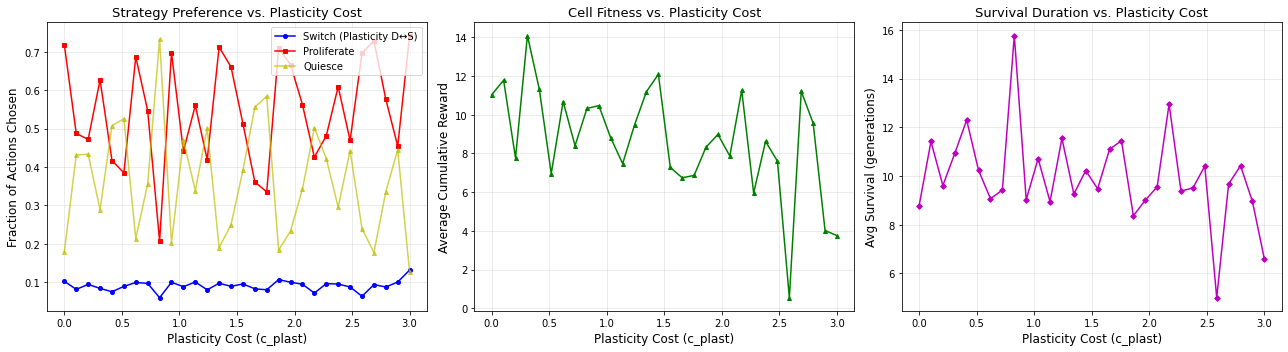

Graph saved to tipping_point.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

costs = results["costs"]

# --- Plot 1: Strategy preference ---
ax1 = axes[0]
ax1.plot(costs, results["switch_fraction"], "b-o", markersize=4, label="Switch (Plasticity D\u2194S)")
ax1.plot(costs, results["proliferate_fraction"], "r-s", markersize=4, label="Proliferate")
ax1.plot(costs, results["quiesce_fraction"], "y-^", markersize=4, label="Quiesce", alpha=0.7)
ax1.set_xlabel("Plasticity Cost (c_plast)", fontsize=12)
ax1.set_ylabel("Fraction of Actions Chosen", fontsize=12)
ax1.set_title("Strategy Preference vs. Plasticity Cost", fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Find and mark the crossover (tipping point): Switch vs Proliferate
switch_arr = np.array(results["switch_fraction"])
prolif_arr = np.array(results["proliferate_fraction"])
crossover_idx = np.where(np.diff(np.sign(switch_arr - prolif_arr)))[0]
if len(crossover_idx) > 0:
    ci = crossover_idx[0]
    tipping_cost = np.interp(0, [switch_arr[ci] - prolif_arr[ci],
                                  switch_arr[ci+1] - prolif_arr[ci+1]],
                              [costs[ci], costs[ci+1]])
    ax1.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2,
                label=f"Tipping point \u2248 {tipping_cost:.2f}")
    ax1.legend()
    print(f">>> TIPPING POINT: Plasticity fails at cost \u2248 {tipping_cost:.2f} <<<")
else:
    print("No clear crossover detected \u2014 try widening the cost range.")

# --- Plot 2: Average reward ---
ax2 = axes[1]
ax2.plot(costs, results["avg_rewards"], "g-^", markersize=4)
ax2.set_xlabel("Plasticity Cost (c_plast)", fontsize=12)
ax2.set_ylabel("Average Cumulative Reward", fontsize=12)
ax2.set_title("Cell Fitness vs. Plasticity Cost", fontsize=13)
ax2.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax2.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

# --- Plot 3: Survival duration ---
ax3 = axes[2]
ax3.plot(costs, results["avg_survival_steps"], "m-D", markersize=4)
ax3.set_xlabel("Plasticity Cost (c_plast)", fontsize=12)
ax3.set_ylabel("Avg Survival (generations)", fontsize=12)
ax3.set_title("Survival Duration vs. Plasticity Cost", fontsize=13)
ax3.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax3.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig("tipping_point.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved to tipping_point.png")

## Q-Table Analysis

Shows the learned policy at low vs. high plasticity cost to verify the tipping-point behavior.
At low cost, the agent should prefer **Switch** in dangerous states. At high cost, it should prefer **Proliferate/Quiesce**.

In [11]:
def show_policy(plasticity_cost):
    """Train an agent and display its learned Q-table and preferred actions."""
    agent, _ = train_agent(plasticity_cost=plasticity_cost, num_episodes=1000, max_steps=1000)
    print(f"\n{'='*80}")
    print(f"  Learned Policy at Plasticity Cost = {plasticity_cost:.2f}")
    print(f"{'='*80}")
    print(f"\n{'State':<24} | {'Best Action':<14} | Q-values [Prolif, Quiesce, Switch]")
    print("-" * 80)
    for s in range(BioConfig.NUM_STATES):
        if np.any(agent.q_table[s] != 0):
            best_a = int(np.argmax(agent.q_table[s]))
            q_vals = ", ".join(f"{q:+.2f}" for q in agent.q_table[s])
            print(f"{BioConfig.state_label(s):<24} | {BioConfig.ACTIONS[best_a]:<14} | [{q_vals}]")

# Compare low cost (plasticity should win) vs high cost (proliferate should win)
show_policy(0.1)
show_policy(2.0)


  Learned Policy at Plasticity Cost = 0.10

State                    | Best Action    | Q-values [Prolif, Quiesce, Switch]
--------------------------------------------------------------------------------
D|G0|Toff|RL|HL          | Proliferate    | [+1.28, +0.99, -0.17]
D|G0|Toff|RL|HH          | Proliferate    | [+2.10, +0.55, +1.91]
D|G0|Toff|RH|HL          | Switch         | [+0.77, +2.28, +7.03]
D|G0|Toff|RH|HH          | Switch         | [-0.91, +1.24, +5.20]
D|G0|Ton|RL|HL           | Switch         | [-1.43, -0.92, +3.81]
D|G0|Ton|RL|HH           | Switch         | [-2.83, -2.02, +3.66]
D|G0|Ton|RH|HL           | Switch         | [-1.88, +0.61, +5.15]
D|G0|Ton|RH|HH           | Switch         | [-0.48, +0.28, +2.57]
D|G1|Toff|RH|HL          | Quiesce        | [-0.46, +0.00, +0.00]
S|G0|Toff|RL|HL          | Proliferate    | [+5.93, +3.65, +0.93]
S|G0|Toff|RL|HH          | Proliferate    | [+9.67, +2.29, -0.37]
S|G0|Toff|RH|HL          | Proliferate    | [+9.85, +5.65, +5.18]
S|G